## Singular Value Decompositions




• Read the image1.jpg from the first assignment. Convert it to a grayscale image. Normalize it between (0,1).

• Take a singular value decomposition of the image.

• Reconstruct the image from with the largest singular value.

• Reconstruct the image from with the largest 10, 20, 50, 100 singular values.

In [32]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Helper functions

In [8]:
def read_and_preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image at path {image_path} could not be loaded.")
    img_gray = img.astype(np.float64) / 255.0  # Normalize to [0, 1]
    return img_gray

In [26]:
def compute_svd_and_singular_values(I: np.ndarray, plot: bool = True):
    # Compute SVD
    U, S, VT = np.linalg.svd(I, full_matrices=False)

    # Report
    print(f"Total singular values: {len(S)}")
    print(f"Shape of U: {U.shape}, Shape of S: {S.shape}, Shape of VT: {VT.shape}")

    # Optional plot
    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(S, marker='.')
        plt.title("Singular Values")
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.grid(True)
        plt.show()

    return U, S, VT

In [28]:
def print_singular_values(S, k=10):
    num = min(k, len(S))
    print(f"First {k} singular values:")
    for i in range(k):
        print(f"{i+1:>2d}: {S[i]:.6f}")

In [10]:
def reconstruct_image(U, S, VT, k):
    u = U[:, :k]
    s = S[:k]
    vt = VT[:k, :]
    reconstructed_image = u @ np.diag(s) @ vt
    reconstructed_image = np.clip(reconstructed_image, 0, 1)  # Ensure values are in [0, 1]
    return reconstructed_image

## Load and preprocess

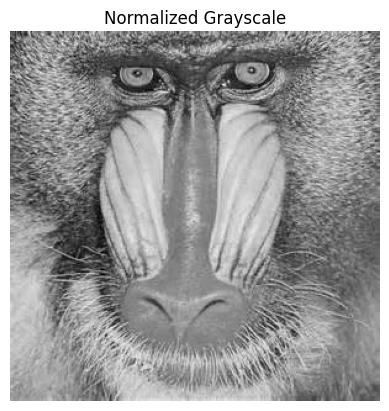

In [11]:
img = read_and_preprocess_image("image1.jpg")
plt.imshow(img, cmap='gray')
plt.title("Normalized Grayscale")
plt.axis('off')
plt.show()

## Compute SVD

Total singular values: 300
Shape of U: (300, 300), Shape of S: (300,), Shape of VT: (300, 300)


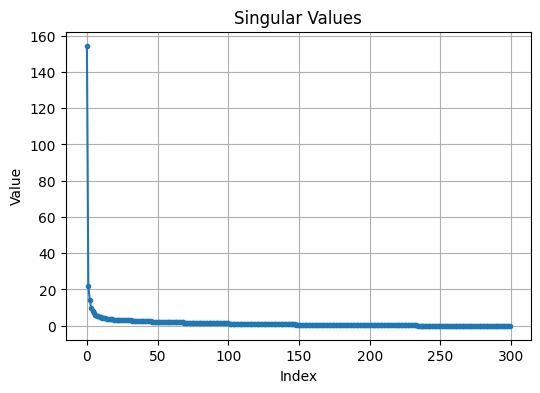

First 10 singular values:
 1: 154.451477
 2: 21.966928
 3: 14.308119
 4: 10.045254
 5: 8.188178
 6: 6.748823
 7: 5.918501
 8: 5.397532
 9: 5.183424
10: 4.876258


In [29]:
U, S, VT = compute_svd_and_singular_values(img, True)
print_singular_values(S, k=10)

## Reconstruction for Highest k

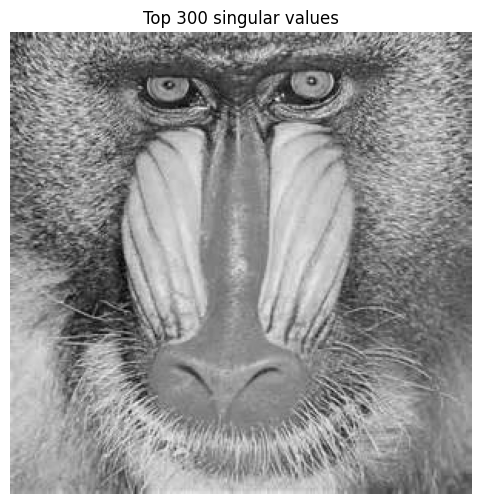

Saved: reconstructed_images/Highest_k.png


In [36]:
# Reconstruct image for highest k
k = len(S) # Use all singular values for highest quality
I_k = reconstruct_image(U, S, VT, k)
I_k_clipped = np.clip(I_k, 0, 1)

# Display in notebook
plt.figure(figsize=(6, 6))
plt.imshow(I_k_clipped, cmap='gray')
plt.title(f"Top {k} singular values")
plt.axis('off')
plt.show()

# Save high-quality image
save_path = os.path.join(output_dir, f"Highest_k.png")
plt.imsave(save_path, I_k_clipped, cmap='gray')
print(f"Saved: {save_path}")

## Reconstructions for multiple k

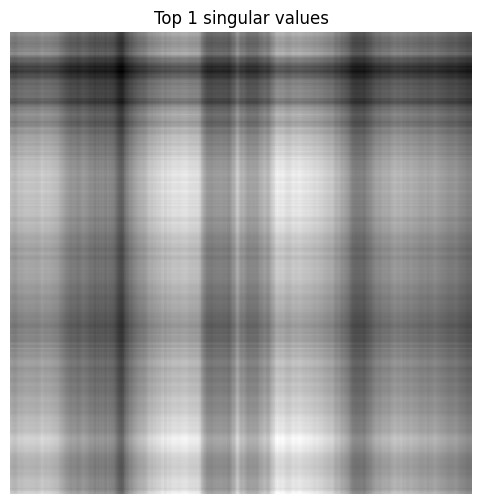

Saved: reconstructed_images/reconstruction_top_1.png


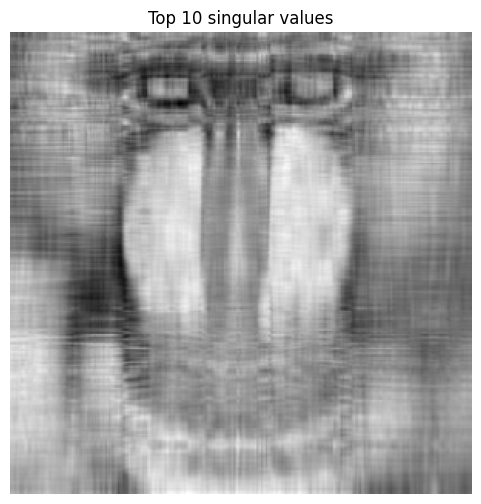

Saved: reconstructed_images/reconstruction_top_10.png


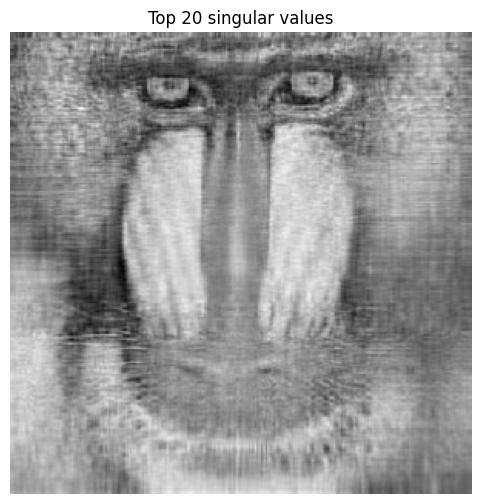

Saved: reconstructed_images/reconstruction_top_20.png


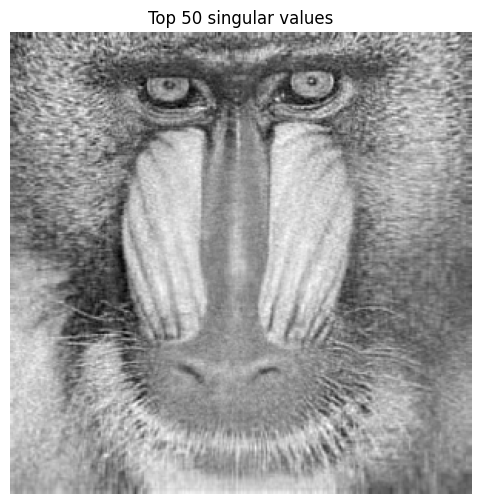

Saved: reconstructed_images/reconstruction_top_50.png


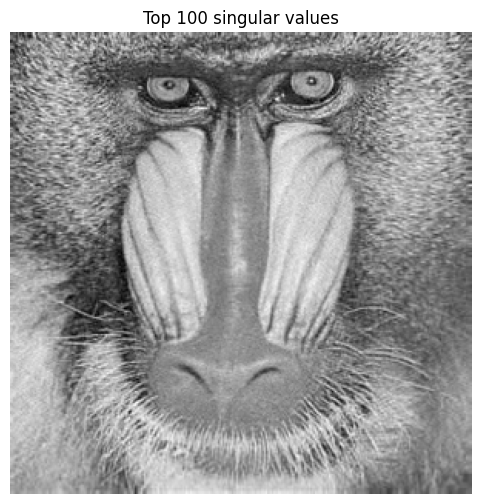

Saved: reconstructed_images/reconstruction_top_100.png


In [34]:
ks = [1, 10, 20, 50, 100]
output_dir = "reconstructed_images"
os.makedirs(output_dir, exist_ok=True)

for k in ks:
    # Reconstruct image
    I_k = reconstruct_image(U, S, VT, k)
    I_k_clipped = np.clip(I_k, 0, 1)
    
    # Display in notebook
    plt.figure(figsize=(6, 6))
    plt.imshow(I_k_clipped, cmap='gray')
    plt.title(f"Top {k} singular values")
    plt.axis('off')
    plt.show()
    
    # Save high-quality image
    save_path = os.path.join(output_dir, f"reconstruction_top_{k}.png")
    plt.imsave(save_path, I_k_clipped, cmap='gray')
    print(f"Saved: {save_path}")


## Rank-1 reconstruction separately

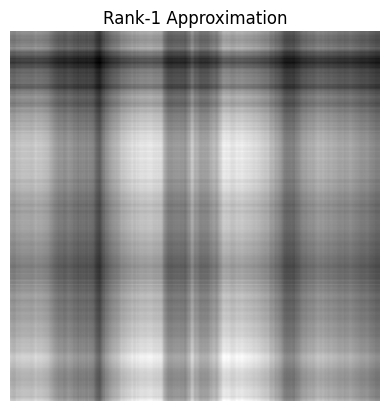

In [16]:
u1 = U[:, 0]
v1 = VT[0, :]
sigma1 = S[0]

I_rank1 = sigma1 * np.outer(u1, v1)

plt.imshow(np.clip(I_rank1, 0, 1), cmap='gray')
plt.title("Rank-1 Approximation")
plt.axis('off')
plt.show()
